In [26]:
# Imports
import os
HEADLESS = False
if HEADLESS:
    os.environ.setdefault("SDL_VIDEODRIVER", "dummy")
    os.environ.setdefault("SDL_AUDIODRIVER", "dummy")

import gymnasium as gym
import highway_env
import math
import random
import time
import statistics as stats
from dataclasses import asdict

import matplotlib
import matplotlib.pyplot as plt

from collections import namedtuple, deque
from itertools import count
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from shared_core_config import SHARED_CORE_CONFIG, SHARED_CORE_ENV_ID

# matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print("device:", device)

device: cpu


In [13]:
# environment
def make_env(seed, render=False):
    config = dict(SHARED_CORE_CONFIG)
    render_mode = None
    if render:
        config["offscreen_rendering"] = HEADLESS
        render_mode = "rgb_array"

    env = gym.make(SHARED_CORE_ENV_ID, config=config, render_mode=render_mode)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return env

In [14]:
# config for experiments
@dataclass
class DQNConfig:
    batch_size: int = 32
    gamma: float = 0.8
    eps_start: float = 1.0
    eps_end: float = 0.05
    eps_decay: int = 5000
    target_update_every: int = 50
    lr: float = 5e-4
    learning_starts: int = 200
    replay_capacity: int = 15000
    hidden_size: int = 256

    num_episodes: int = int(2e4)
    eval_episodes: int = 25
    checkpoint_every: int = 100
    best_avg_window: int = 20

In [16]:
# Replay buffer + network
Transition = namedtuple(
    "Transition",
    ("state", "action", "next_state", "reward")
)

class ReplayBuffer:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)


class Net(nn.Module):
    def __init__(self, n_obs, n_actions, hidden_size=256):
        super().__init__()
        self.layer1 = nn.Linear(n_obs, hidden_size)
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.layer3 = nn.Linear(hidden_size, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

In [17]:
# utilities
def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def to_state_tensor(obs):
    return torch.tensor(obs, dtype=torch.float32, device=device).view(1, -1)

In [25]:
# checkpoint utilities
RUN_ID = time.strftime("%Y%m%d-%H%M%S")
CHECKPOINT_DIR = os.path.join("checkpoints", f"run_{RUN_ID}")
print("Checkpoint dir:", CHECKPOINT_DIR)

def save_checkpoint(path, agent, episode, episode_rewards):
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    torch.save(
        {
            "policy_state_dict": agent.policy_net.state_dict(),
            "target_state_dict": agent.target_net.state_dict(),
            "optimizer_state_dict": agent.optimizer.state_dict(),
            "steps_done": agent.steps_done,
            "episode": episode,
            "seed": agent.seed,
            "episode_rewards": episode_rewards,
            "config": asdict(agent.cfg)
        },
        path,
    )

Checkpoint dir: checkpoints\run_20260320-161525


In [19]:
# DQN Agent
class DQNAgent:

    def __init__(self, env, cfg: DQNConfig, seed):
        self.env = env
        self.cfg = cfg
        self.seed = seed

        set_seed(seed)

        state, _ = env.reset(seed=seed)
        self.n_observations = int(torch.tensor(state).numel())
        self.n_actions = env.action_space.n

        self.policy_net = Net(self.n_observations, self.n_actions, cfg.hidden_size).to(device)
        self.target_net = Net(self.n_observations, self.n_actions, cfg.hidden_size).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        self.optimizer = optim.AdamW(self.policy_net.parameters(), lr=cfg.lr, amsgrad=True)
        self.memory = ReplayBuffer(cfg.replay_capacity)

        self.steps_done = 0

    def select_action(self, state):
        sample = random.random()

        eps_threshold = self.cfg.eps_end + (
            self.cfg.eps_start - self.cfg.eps_end
        ) * math.exp(-1. * self.steps_done / self.cfg.eps_decay)

        self.steps_done += 1

        if sample > eps_threshold:
            with torch.no_grad():
                return self.policy_net(state).max(1).indices.view(1, 1)
        else:
            return torch.tensor(
                [[self.env.action_space.sample()]],
                device=device,
                dtype=torch.long
            )
        
    def optimize(self):
        if len(self.memory) < self.cfg.batch_size:
            return

        transitions = self.memory.sample(self.cfg.batch_size)
        batch = Transition(*zip(*transitions))

        non_final_mask = torch.tensor(
            tuple(map(lambda s: s is not None, batch.next_state)),
            device=device,
            dtype=torch.bool
        )

        non_final_next_states = [s for s in batch.next_state if s is not None]
        if len(non_final_next_states) > 0:
            non_final_next_states = torch.cat(non_final_next_states)
        else:
            non_final_next_states = torch.empty((0, self.n_observations), device=device)

        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)

        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        next_state_values = torch.zeros(self.cfg.batch_size, device=device)
        with torch.no_grad():
            if non_final_next_states.numel() > 0:
                next_state_values[non_final_mask] = (
                    self.target_net(non_final_next_states).max(1).values
                )

        expected = (next_state_values * self.cfg.gamma) + reward_batch

        loss = nn.SmoothL1Loss()(state_action_values, expected.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

    def train(self, plot_fn=None):
        episode_rewards = []
        episode_lengths = []
        best_avg_reward = float("-inf")

        for i_episode in range(self.cfg.num_episodes):

            state, _ = self.env.reset(seed=self.seed + i_episode)
            state = to_state_tensor(state)

            total_reward = 0.0

            for t in count():
                action = self.select_action(state)

                observation, reward, terminated, truncated, _ = self.env.step(action.item())
                total_reward += reward

                reward_t = torch.tensor([reward], device=device)
                done = terminated or truncated

                next_state = None if done else to_state_tensor(observation)

                self.memory.push(state, action, next_state, reward_t)
                state = next_state

                if len(self.memory) >= max(self.cfg.batch_size, self.cfg.learning_starts):
                    self.optimize()

                if self.steps_done % self.cfg.target_update_every == 0:
                    self.target_net.load_state_dict(self.policy_net.state_dict())

                if done:
                    episode_rewards.append(total_reward)
                    episode_lengths.append(t + 1)

                    if plot_fn:
                        plot_fn(episode_rewards)

                    break

            # periodic checkpoint
            if (i_episode + 1) % self.cfg.checkpoint_every == 0:
                ckpt_path = os.path.join(
                    CHECKPOINT_DIR,
                    f"seed{self.seed}_ep{i_episode + 1}.pt"
                )
                save_checkpoint(ckpt_path, self, i_episode + 1, episode_rewards)

            # best model checkpoint
            if len(episode_rewards) >= self.cfg.best_avg_window:
                window_avg = stats.mean(
                    episode_rewards[-self.cfg.best_avg_window:]
                )

                if window_avg > best_avg_reward:
                    best_avg_reward = window_avg
                    best_path = os.path.join(
                        CHECKPOINT_DIR,
                        f"seed{self.seed}_best.pt"
                    )
                    save_checkpoint(best_path, self, i_episode + 1, episode_rewards)

        return episode_rewards, episode_lengths
        

In [20]:
# Plotting
def plot_training(rewards, show_result=False):
    plt.figure(1)
    rewards_t = torch.tensor(rewards, dtype=torch.float)

    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')

    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.plot(rewards_t.numpy())

    if len(rewards_t) >= 100:
        means = rewards_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)

    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [21]:
# evaluation
def evaluate_policy(env, policy_net, n_episodes, seed_offset):
    policy_net.eval()

    rewards = []
    lengths = []

    with torch.no_grad():
        for i in range(n_episodes):
            state, _ = env.reset(seed=seed_offset + i)
            state = to_state_tensor(state)

            total_reward = 0

            for t in count():
                action = policy_net(state).max(1).indices.view(1, 1)
                obs, reward, terminated, truncated, _ = env.step(action.item())

                total_reward += reward
                done = terminated or truncated

                if done:
                    rewards.append(total_reward)
                    lengths.append(t + 1)
                    break

                state = to_state_tensor(obs)

    policy_net.train()
    return stats.mean(rewards), stats.mean(lengths)

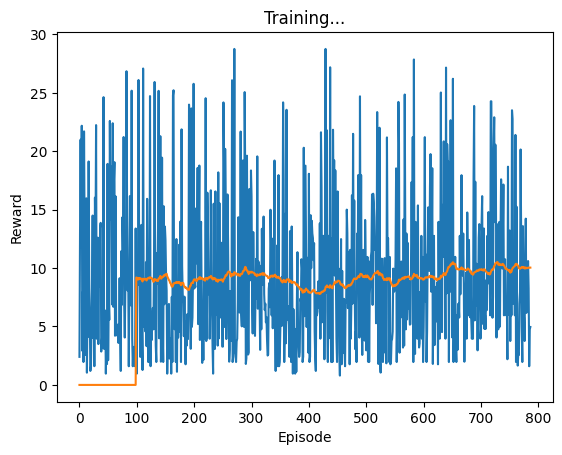

<Figure size 640x480 with 0 Axes>

In [ ]:
# Run experiment
if device == 'cpu' :
    cfg = DQNConfig()
else :
    cfg = DQNConfig(num_episodes=200000)


SEEDS = [0, 1, 2, 3, 4, 5]

results = []
all_seed_rewards = []
all_seed_lengths = []

for run_seed in SEEDS:

    set_seed(run_seed)

    env = make_env(run_seed)

    agent = DQNAgent(env, cfg, run_seed)

    rewards, lengths = agent.train(plot_fn=plot_training)

    eval_env = make_env(run_seed + 1000)

    avg_eval_reward, avg_eval_length = evaluate_policy(
        eval_env,
        agent.policy_net,
        cfg.eval_episodes,
        run_seed + 2000
    )

    eval_env.close()
    env.close()

    results.append({
        "seed": run_seed,
        "avg_eval_reward": avg_eval_reward,
        "avg_eval_length": avg_eval_length,
    })

    all_seed_rewards.append(rewards)
    all_seed_lengths.append(lengths)

print("Training complete")

In [ ]:
print('| seed | avg_eval_reward | avg_eval_length |')
print('| --- | --- | --- |')

for row in results:
    print(f"| {row['seed']} | {row['avg_eval_reward']:.2f} | {row['avg_eval_length']:.2f} |")